In [1]:
import io
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
zip_file_path = '../data/logs/round_1/196128.zip'

In [110]:
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

In [111]:
data_json.keys()

dict_keys(['round', 'status', 'profit', 'activitiesLog', 'graphLog', 'positions'])

In [112]:
data_log.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [113]:
activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

In [114]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

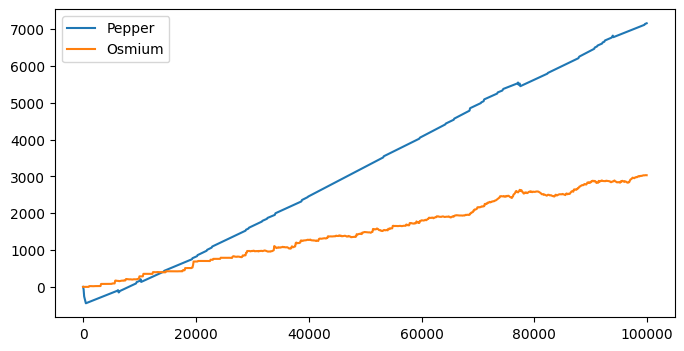

In [115]:
plt.figure(figsize=(8, 4))
plt.plot(price_pepper['profit_and_loss'], label='Pepper')
plt.plot(price_osmium['profit_and_loss'], label='Osmium')
plt.legend()
plt.show()

In [107]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 7159.625
Pepper Min PnL: -445.5
Osmium Final PnL: 3111.4375
Osmium Min PnL: 0.0


In [116]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 7159.625
Pepper Min PnL: -445.5
Osmium Final PnL: 3032.5
Osmium Min PnL: 0.0


In [73]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

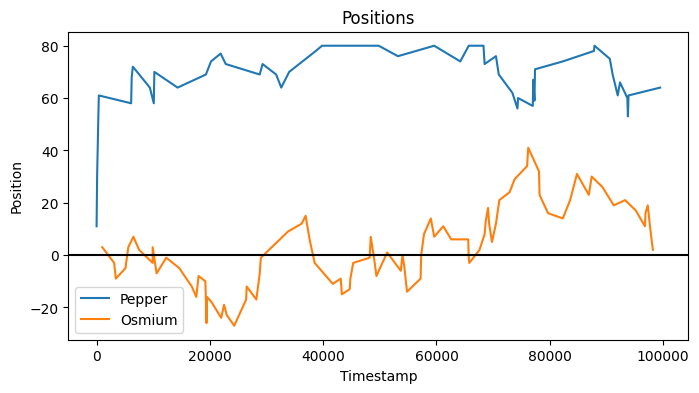

In [74]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()